## Práctica 6: Umbralización global y local de imágenes
### Autor: Juan Manuel Mena Hernandez
### Fecha: 07-04-2026


### EJERCICIO 1. UMBRALIZACION GLOBAL SIMPLE (BINARIZACIÓN)


En este ejercicio se pide aplicar la forma más básica de segmentación. Si el píxel supera un valor T, se asigna el máximo (255), de lo contrario, se asigna 0. Es ideal cuando el histograma es claramente bimodal

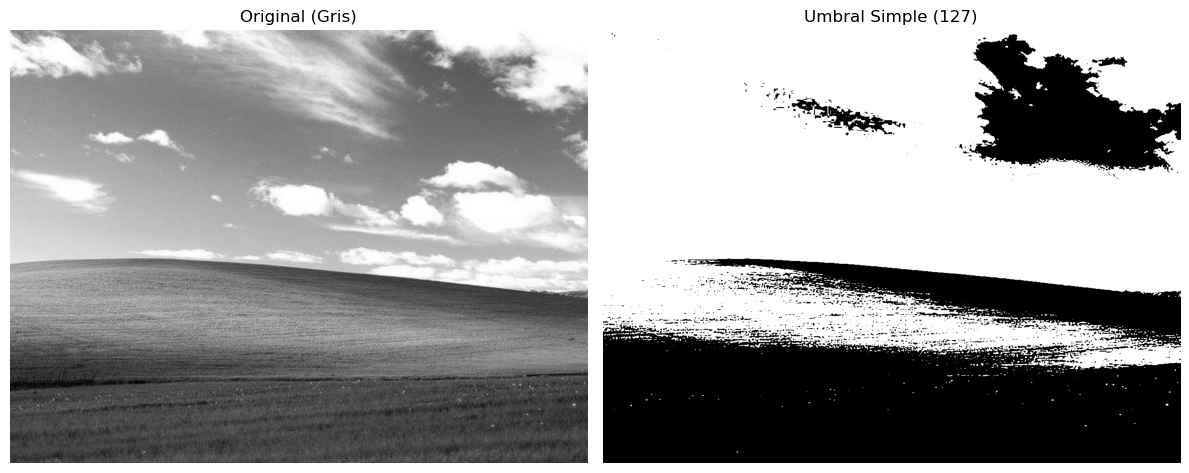

In [1]:
import cv2
import matplotlib.pyplot as plt

# Cargar imagen en escala de grises
img = cv2.imread("imagen.jpg", 0)

if img is None:
    raise FileNotFoundError("No se encontró 'imagen.jpg'. Verifica la ruta o el nombre del archivo.")

# Umbralización global simple:
# píxeles <= 127 -> 0, píxeles > 127 -> 255
_, res = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Mostrar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(img, cmap="gray")
ax1.set_title("Original (Gris)")
ax1.axis("off")

ax2.imshow(res, cmap="gray")
ax2.set_title("Umbral Simple (127)")
ax2.axis("off")

plt.tight_layout()
plt.show()

Para convertir una fotografía normal en una imagen de alto contraste usando solo blanco y negro puro hacemos estos pasos:

Primero, intenta cargar tu fotografía directamente en escala de grises y verifica que el archivo exista.

Segundo, aplica un proceso llamado "umbralización simple". El programa revisa el brillo de cada píxel de la foto; si el valor supera la marca exacta de 127, lo pinta completamente de blanco, y si es igual o menor, lo oscurece hasta convertirlo en negro absoluto, eliminando de golpe todos los tonos grises intermedios.

Tercero, dibuja una ventana dividida en dos paneles para mostrarte la foto original a la izquierda y el resultado binario a la derecha.

### EJERCICIO 2. APLICAR UMBRALIZACIÖN DE MANERA MANUAL UTILIZANDO LOS METODOS DE UMBRALIZACIÓN GLOBAL INVERTIDA (BINARY INV), TRUNCADA(TRUNC) Y A CERO (TOZERO)

En este ejercicio se pide aplicar la umbralización de una imagen de manera manual mediante los métodos citados y comparar sus resultados. Se utilizará un valor de T fijo = 127.

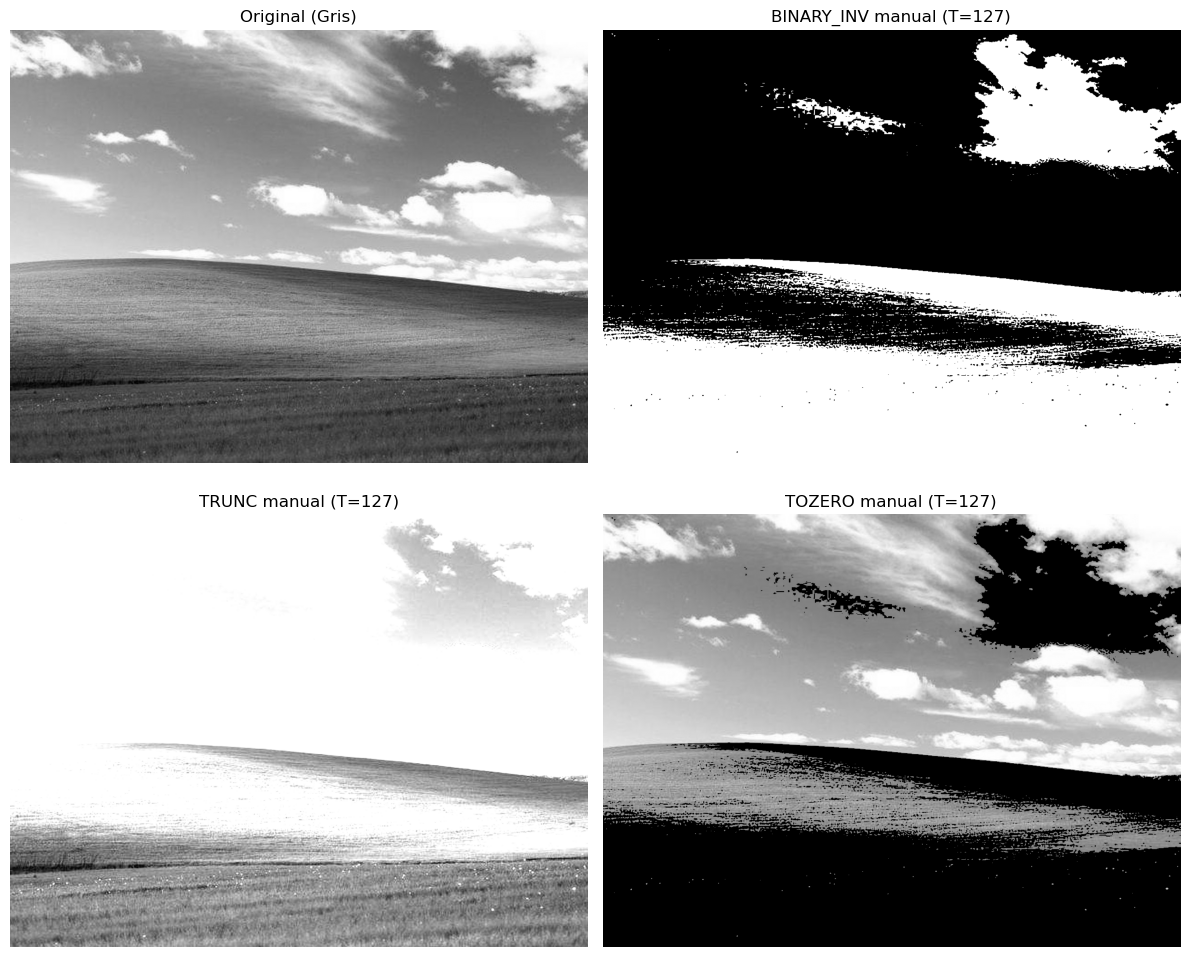

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen en escala de grises
img = cv2.imread("imagen.jpg", 0)

if img is None:
    raise FileNotFoundError("No se encontró 'imagen.jpg'. Verifica la ruta o el nombre del archivo.")

T = 127  # umbral fijo

# Manual con NumPy
# 1) BINARY_INV: <=T -> 255, >T -> 0
res_inv = np.where(img > T, 0, 255).astype(np.uint8)

# 2) TRUNC: >T -> T, <=T se mantiene
res_trunc = np.where(img > T, T, img).astype(np.uint8)

# 3) TOZERO: <=T -> 0, >T se mantiene
res_tozero = np.where(img > T, img, 0).astype(np.uint8)

# Mostrar comparación
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("Original (Gris)")
axes[0, 0].axis("off")

axes[0, 1].imshow(res_inv, cmap="gray")
axes[0, 1].set_title("BINARY_INV manual (T=127)")
axes[0, 1].axis("off")

axes[1, 0].imshow(res_trunc, cmap="gray")
axes[1, 0].set_title("TRUNC manual (T=127)")
axes[1, 0].axis("off")

axes[1, 1].imshow(res_tozero, cmap="gray")
axes[1, 1].set_title("TOZERO manual (T=127)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

Este código explora diferentes formas de separar y modificar las luces y sombras de una fotografía.

Primero, intenta cargar tu imagen directamente en blanco y negro y verifica que el archivo exista.

Segundo, aplica tres variaciones matemáticas diferentes de "umbral" utilizando el valor 127 como punto de corte:

Umbral invertido: Funciona exactamente al revés que un filtro blanco y negro normal; convierte los tonos oscuros en blanco puro y los tonos claros en negro absoluto.

Umbral truncado: Actúa como un "techo" de luz; los grises oscuros se quedan tal como estaban, pero cualquier zona brillante o más clara que el nivel 127 se oscurece para no superar jamás ese límite.

Umbral a cero: Actúa como un "piso"; borra por completo las zonas oscuras volviéndolas negro absoluto, pero deja las zonas claras de la foto completamente intactas.

Por último, dibuja una gran ventana dividida en una cuadrícula para observar la fotografía original en la esquina superior izquierda y compararla simultáneamente con el efecto visual que produce cada uno de estos tres métodos.

### EJERCICIO 3. BINARIZACION AUTOMÁTICA MEDIANTE EL MÉTODO DE OTSU

En este ejercicio se pide aplicar umbralización global binarizada de manera automática mediante el método de Otsu. Otsu calcula automáticamente el umbral óptimo minimizando la varianza dentro de cada clase. Es el est´andar de oro para imágenes con histogramas bimodales bien definidos


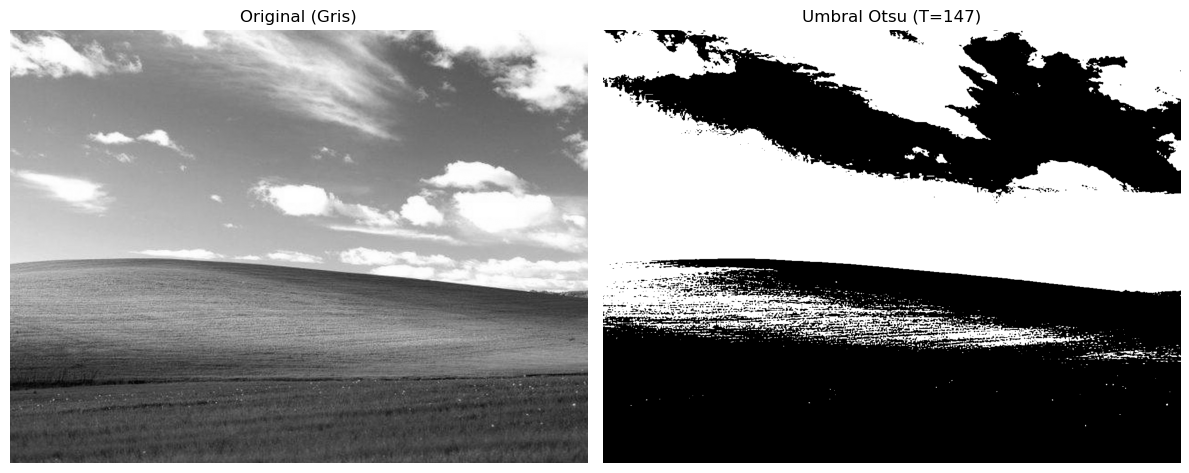

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Cargar imagen en escala de grises
img = cv2.imread("imagen.jpg", 0)

if img is None:
    raise FileNotFoundError("No se encontró 'imagen.jpg'. Verifica la ruta o el nombre del archivo.")

# Umbralización automática con Otsu
val, res = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Mostrar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(img, cmap="gray")
ax1.set_title("Original (Gris)")
ax1.axis("off")

ax2.imshow(res, cmap="gray")
ax2.set_title(f"Umbral Otsu (T={val:.0f})")
ax2.axis("off")

plt.tight_layout()
plt.show()

Seguimos estos pasos:

En primer lugar, se intenta cargar tu imagen directamente en blanco y negro y verifica que el archivo exista.

Luego, aplica la umbralización de "Otsu". Este algoritmo analiza matemáticamente la estadística de todos los tonos grises presentes en la foto, es decir, su histograma y calcula por sí solo el punto de corte perfecto que mejor separa el fondo de los objetos principales.

En el último paso, dibuja una ventana dividida  para mostrarte la foto original a la izquierda y el resultado final a la derecha. Se indica cuál fue el valor de T quese calculó de forma automática para hacer la separación

### EJERCICIO 4. UMBRALIZACIÓN ADAPTATIVA GAUSSIANA (LOCAL)

En este ejercicio se pide aplicar umbralización adaptativa mediante el método local gaussiana a una imagen a elegir. A diferencia de la media, este método utiliza una suma ponderada gaussiana de la vecindad. Proporciona resultados más limpios en los bordes y es más robusto ante el ruido fino.

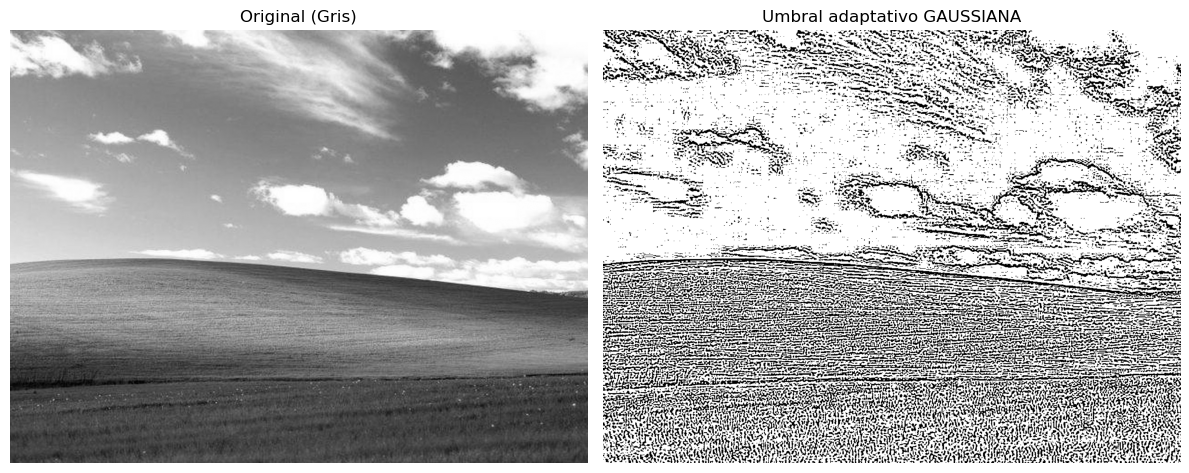

In [4]:
import cv2
import matplotlib.pyplot as plt

# Cargar imagen en escala de grises
img = cv2.imread("imagen.jpg", 0)

if img is None:
    raise FileNotFoundError("No se encontró 'imagen.jpg'. Verifica la ruta o el nombre del archivo.")

# Umbralización adaptativa gaussiana (local)
t_adapt_gauss = cv2.adaptiveThreshold(
    img, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

# Mostrar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(img, cmap="gray")
ax1.set_title("Original (Gris)")
ax1.axis("off")

ax2.imshow(t_adapt_gauss, cmap="gray")
ax2.set_title("Umbral adaptativo GAUSSIANA")
ax2.axis("off")

plt.tight_layout()
plt.show()

Este código convierte una fotografía a blanco y negro adaptándose a los cambios de iluminación en diferentes zonas.

En primer lugar, se intenta cargar tu imagen directamente en blanco y negro y verifica que el archivo exista.

Tras esto, aplica un filtro de "umbralización adaptativa gaussiana". Este algoritmo funciona localmente: analiza la imagen dividiéndola en pequeños bloques de 11x11 píxeles en este caso. Luego, calcula un límite de blanco y negro independiente para cada parte basándose en un promedio suavizado de la luz en esa área.

Al final, dibuja una ventana dividida en dos paneles para mostrarte la foto original a la izquierda y el resultado a la derecha.

### EJERCICIO 5. MÉTODO DEL TRIÁNGULO PARA IMÁGENES UNIMODALES


En este ejercicio se pide aplicar el método del triángulo para imágenes unimodales. Cuando los objetos ocupan una parte muy pequeña de la imagen, el histograma no es bimodal. El método del triángulo busca el punto m´as alejado de la recta principal del histograma para segmentar.

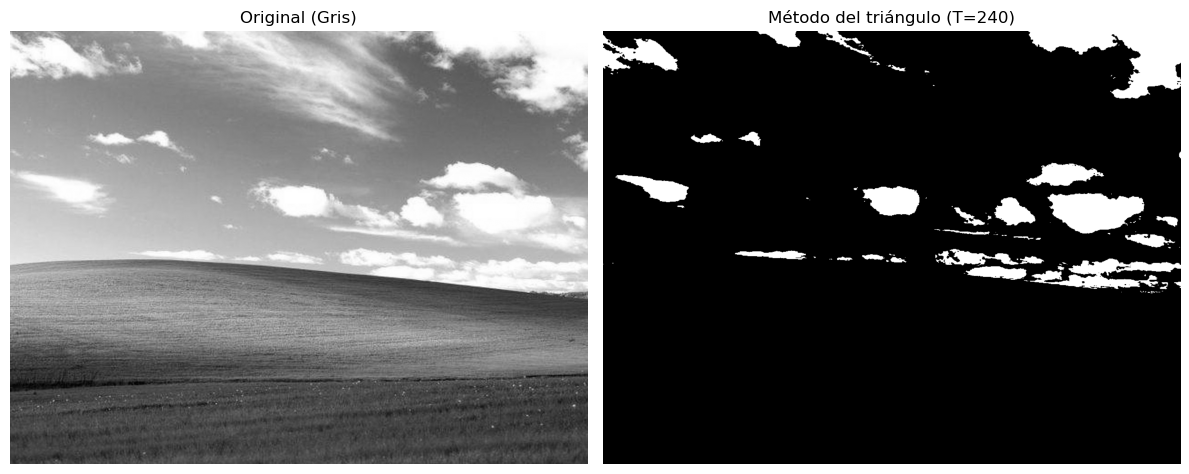

In [5]:
import cv2
import matplotlib.pyplot as plt

# Cargar imagen en escala de grises
img = cv2.imread("imagen.jpg", 0)

if img is None:
    raise FileNotFoundError("No se encontró 'imagen.jpg'. Verifica la ruta o el nombre del archivo.")

# Umbralización automática con método del triángulo
val, res = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

# Mostrar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(img, cmap="gray")
ax1.set_title("Original (Gris)")
ax1.axis("off")

ax2.imshow(res, cmap="gray")
ax2.set_title(f"Método del triángulo (T={val:.0f})")
ax2.axis("off")

plt.tight_layout()
plt.show()

Para este ejercicio realizamos los siguientes pasos:

Primero, se intenta cargar tu imagen directamente en blanco y negro y verifica que el archivo exista.

Segundo, aplica el método de umbralización del "Triángulo". Este método es ideal para imágenes donde predomina un solo tono. Funciona analizando la gráfica de píxeles: dibuja una línea imaginaria entre el punto más alto del histograma y el extremo opuesto gráfica, buscando geométricamente el punto más alejado de esa línea para usarlo como el límite exacto entre el blanco y el negro.

Tercero, dibuja una ventana dividida  para mostrarte la foto original a la izquierda y el resultado final a la derecha. Se indica cuál fue el valor de T quese calculó de forma automática para hacer la separación